In [2]:
import kagglehub

path = kagglehub.dataset_download("phenomsg/waste-classification")

print("Path to dataset files:", path)

100%|██████████| 1.02G/1.02G [00:12<00:00, 90.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/phenomsg/waste-classification/versions/1


In [6]:
pip install tensorflow keras numpy matplotlib scikit-learn

Found 2309 images belonging to 4 classes.
Found 575 images belonging to 4 classes.
Epoch 1/10
 2/73 ━━━━━━━━━━━━━━━━━━━━ 1:17 1s/step - accuracy: 0.2109 - loss: 11.1274

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


 9/73 ━━━━━━━━━━━━━━━━━━━━ 1:07 1s/step - accuracy: 0.2619 - loss: 23.3817

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


73/73 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.2780 - loss: 13.9008 - val_accuracy: 0.2365 - val_loss: 4.0134
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.3162 - loss: 2.3547 - val_accuracy: 0.3409 - val_loss: 1.4591
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.3456 - loss: 1.6094 - val_accuracy: 0.3583 - val_loss: 1.3579
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.4097 - loss: 1.3664 - val_accuracy: 0.2957 - val_loss: 1.5192
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.4435 - loss: 1.3889 - val_accuracy: 0.2609 - val_loss: 1.6124
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.3759 - loss: 1.4586 - val_accuracy: 0.3322 - val_loss: 1.6617
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.4465 - loss: 1.2594 - val_accuracy: 0.2870 - val_loss: 1.4735
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.4712 - loss: 1.2584 - val_accuracy: 0.3322 - val_loss: 1.5627
E

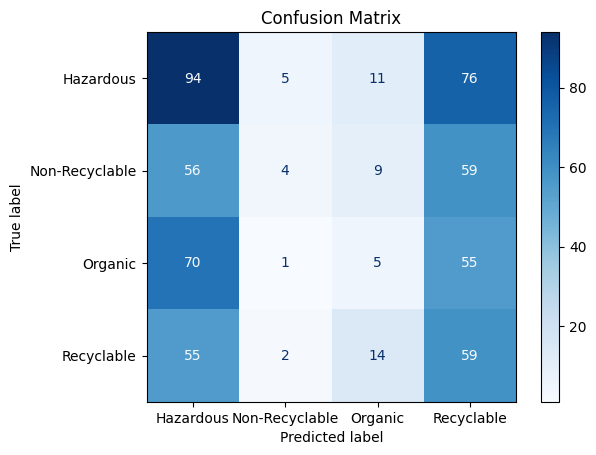

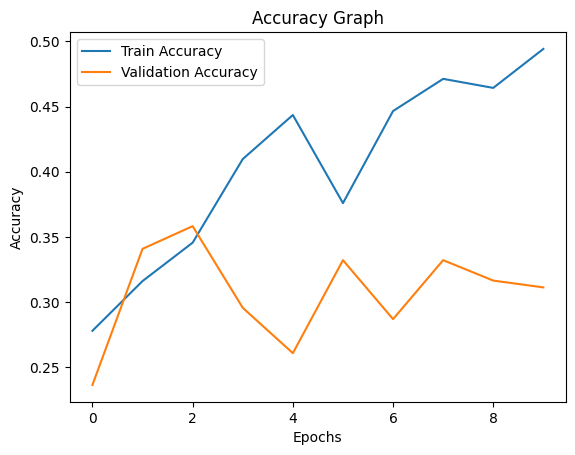


Model training complete and saved!


In [7]:

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

data_dir = path

img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

model = Sequential([
    Input(shape=(128,128,3)),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


val_data.reset()
pred = model.predict(val_data)

y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes


print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(val_data.class_indices.keys())))


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(val_data.class_indices.keys()))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()


model.save("waste_ann_model.h5")

print("\nModel training complete and saved!")